### Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score as sklearn_r2_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from imblearn.over_sampling import SMOTE
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import joblib
import json
import warnings
import os

warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


### Data Loading

In [2]:
df = pd.read_excel(r"C:\Users\HP\Downloads\Nandhini_Majorproject\Dataset for People for their Blood Glucose Level with their Superficial body feature readings..xlsx")

In [3]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (16969, 10)


In [4]:
print("print sample rows:")
df.head(5)

print sample rows:


,Age,Blood Glucose Level(BGL),Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/Diabetic (1/0)
0,9,79,73,118,98,98.300707,99,0,0,0
1,9,80,73,119,102,98.300707,94,1,0,0
2,9,70,76,110,81,98.300707,98,1,0,0
3,9,70,78,115,96,98.300707,96,1,0,0
4,66,100,96,144,92,97.807052,98,0,0,0


In [5]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['Age', 'Blood Glucose Level(BGL)', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/Diabetic (1/0)']


In [6]:
print(f"Data Types:\n{df.dtypes}")

Data Types:
Age                           int64
Blood Glucose Level(BGL)      int64
Diastolic Blood Pressure      int64
Systolic Blood Pressure       int64
Heart Rate                    int64
Body Temperature            float64
SPO2                          int64
Sweating  (Y/N)               int64
Shivering (Y/N)               int64
Diabetic/Diabetic (1/0)       int64
dtype: object


In [7]:
print(f"Missing Values:\n{df.isnull().sum()}")

Missing Values:
Age                         0
Blood Glucose Level(BGL)    0
Diastolic Blood Pressure    0
Systolic Blood Pressure     0
Heart Rate                  0
Body Temperature            0
SPO2                        0
Sweating  (Y/N)             0
Shivering (Y/N)             0
Diabetic/Diabetic (1/0)     0
dtype: int64


### EXPLORATORY DATA ANALYSIS (EDA)

In [8]:
# Rename columns 
df.columns = ['Age', 'BGL', 'DBP', 'SBP', 'HR', 'Temp', 'SPO2', 'Sweating', 'Shivering', 'Diabetic']


def categorize_glucose(bgl):
    if bgl < 70:
        return 0  # Hypoglycemia
    elif 70 <= bgl < 250:  
        return 1  # Normal Glycemia
    else:  # bgl >= 250
        return 2  # Hyperglycemia

df['Glucose_Category'] = df['BGL'].apply(categorize_glucose)
category_names = {0: 'Hypoglycemia', 1: 'Normal', 2: 'Hyperglycemia'}

In [9]:
print("GLUCOSE CATEGORY DISTRIBUTION")
category_dist = df['Glucose_Category'].value_counts().sort_index()
for cat, count in category_dist.items():
    print(f"{category_names[cat]}: {count} ({count/len(df)*100:.2f}%)")

GLUCOSE CATEGORY DISTRIBUTION
Hypoglycemia: 5147 (30.33%)
Normal: 11739 (69.18%)
Hyperglycemia: 83 (0.49%)


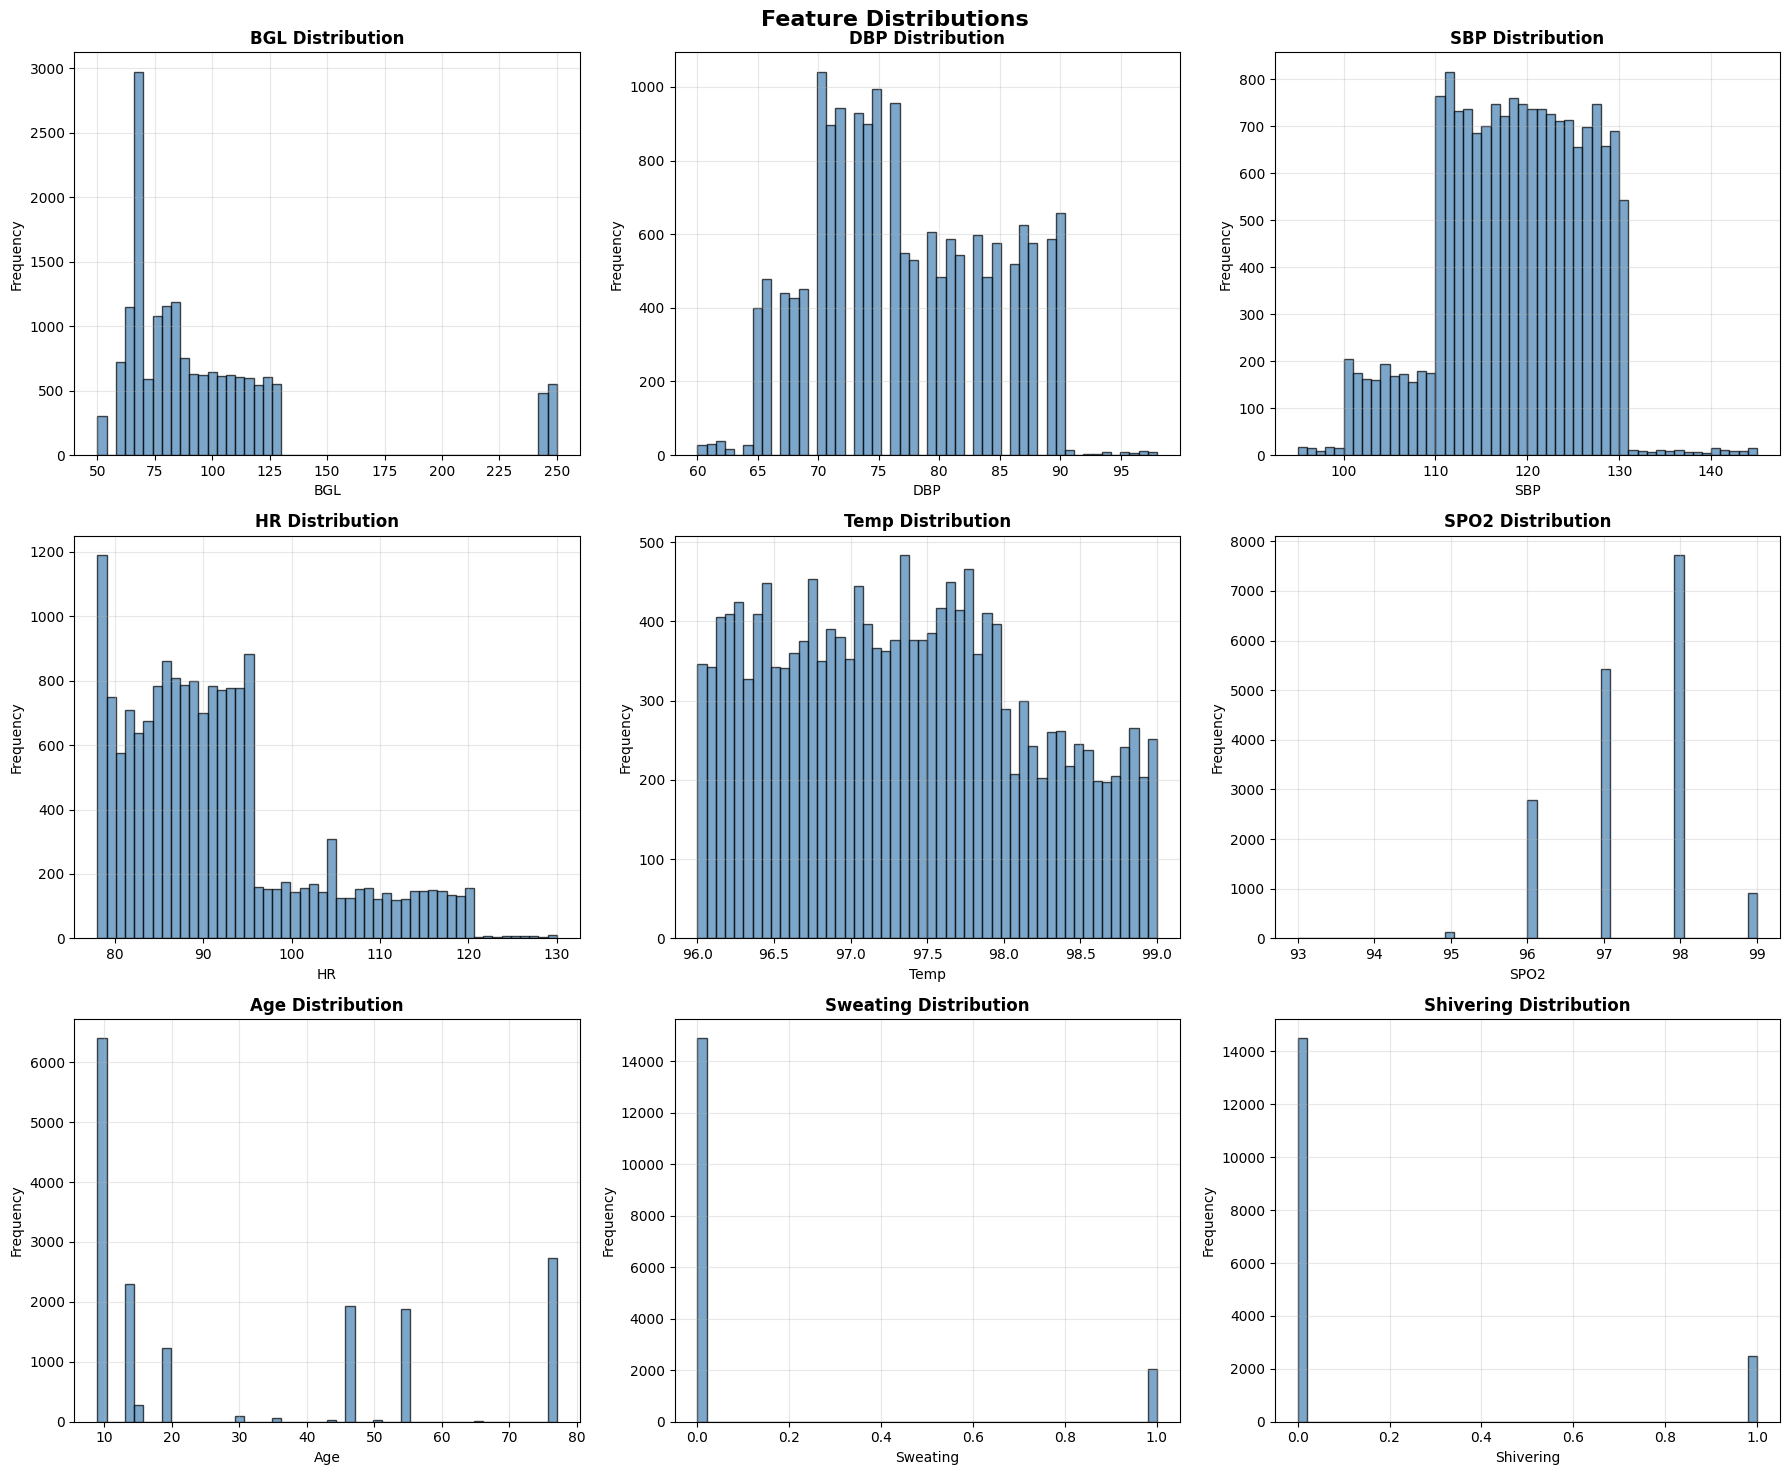

In [10]:
#Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

features = ['BGL', 'DBP', 'SBP', 'HR', 'Temp', 'SPO2', 'Age', 'Sweating', 'Shivering']
for idx, feature in enumerate(features):
    ax = axes[idx//3, idx%3]
    ax.hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature} Distribution', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

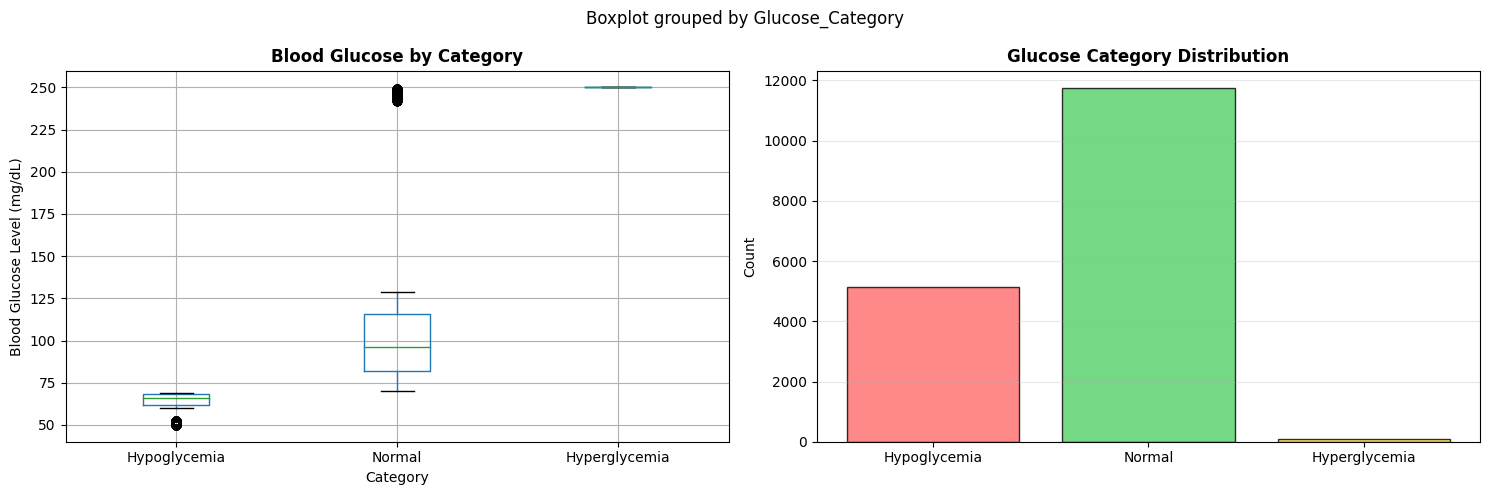

In [11]:
#Glucose level by category
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
df.boxplot(column='BGL', by='Glucose_Category', ax=axes[0])
axes[0].set_title('Blood Glucose by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Blood Glucose Level (mg/dL)')
plt.sca(axes[0])
plt.xticks([1, 2, 3], ['Hypoglycemia', 'Normal', 'Hyperglycemia'])

# Count plot
all_categories = [0, 1, 2]
category_names = ['Hypoglycemia', 'Normal', 'Hyperglycemia']
category_counts = df['Glucose_Category'].value_counts()
category_counts = category_counts.reindex(all_categories, fill_value=0)

axes[1].bar(category_names, 
            category_counts.values, 
            color=['#ff6b6b', '#51cf66', '#ffd43b'],
            edgecolor='black', alpha=0.8)
axes[1].set_title('Glucose Category Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

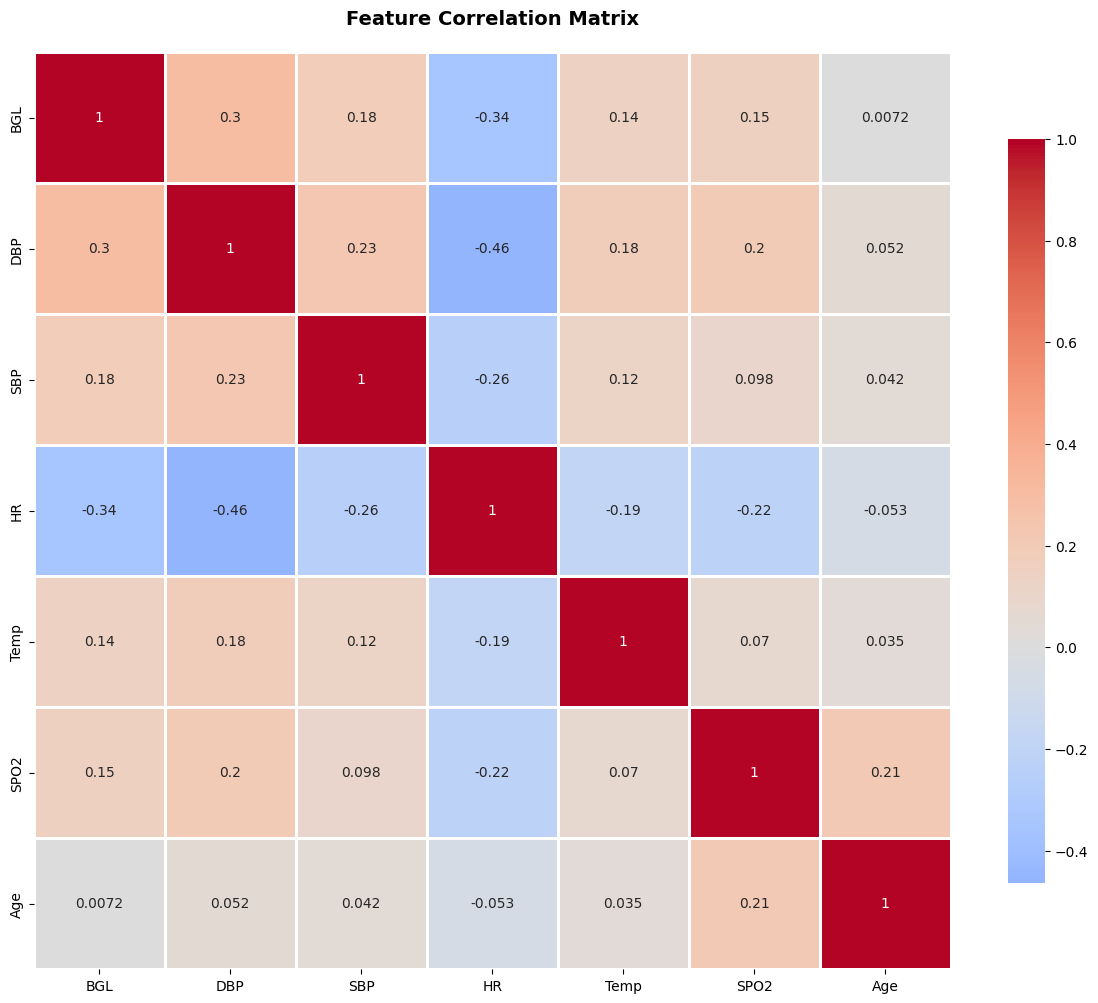

In [12]:
#Correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df[['BGL', 'DBP', 'SBP', 'HR', 'Temp', 'SPO2', 'Age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

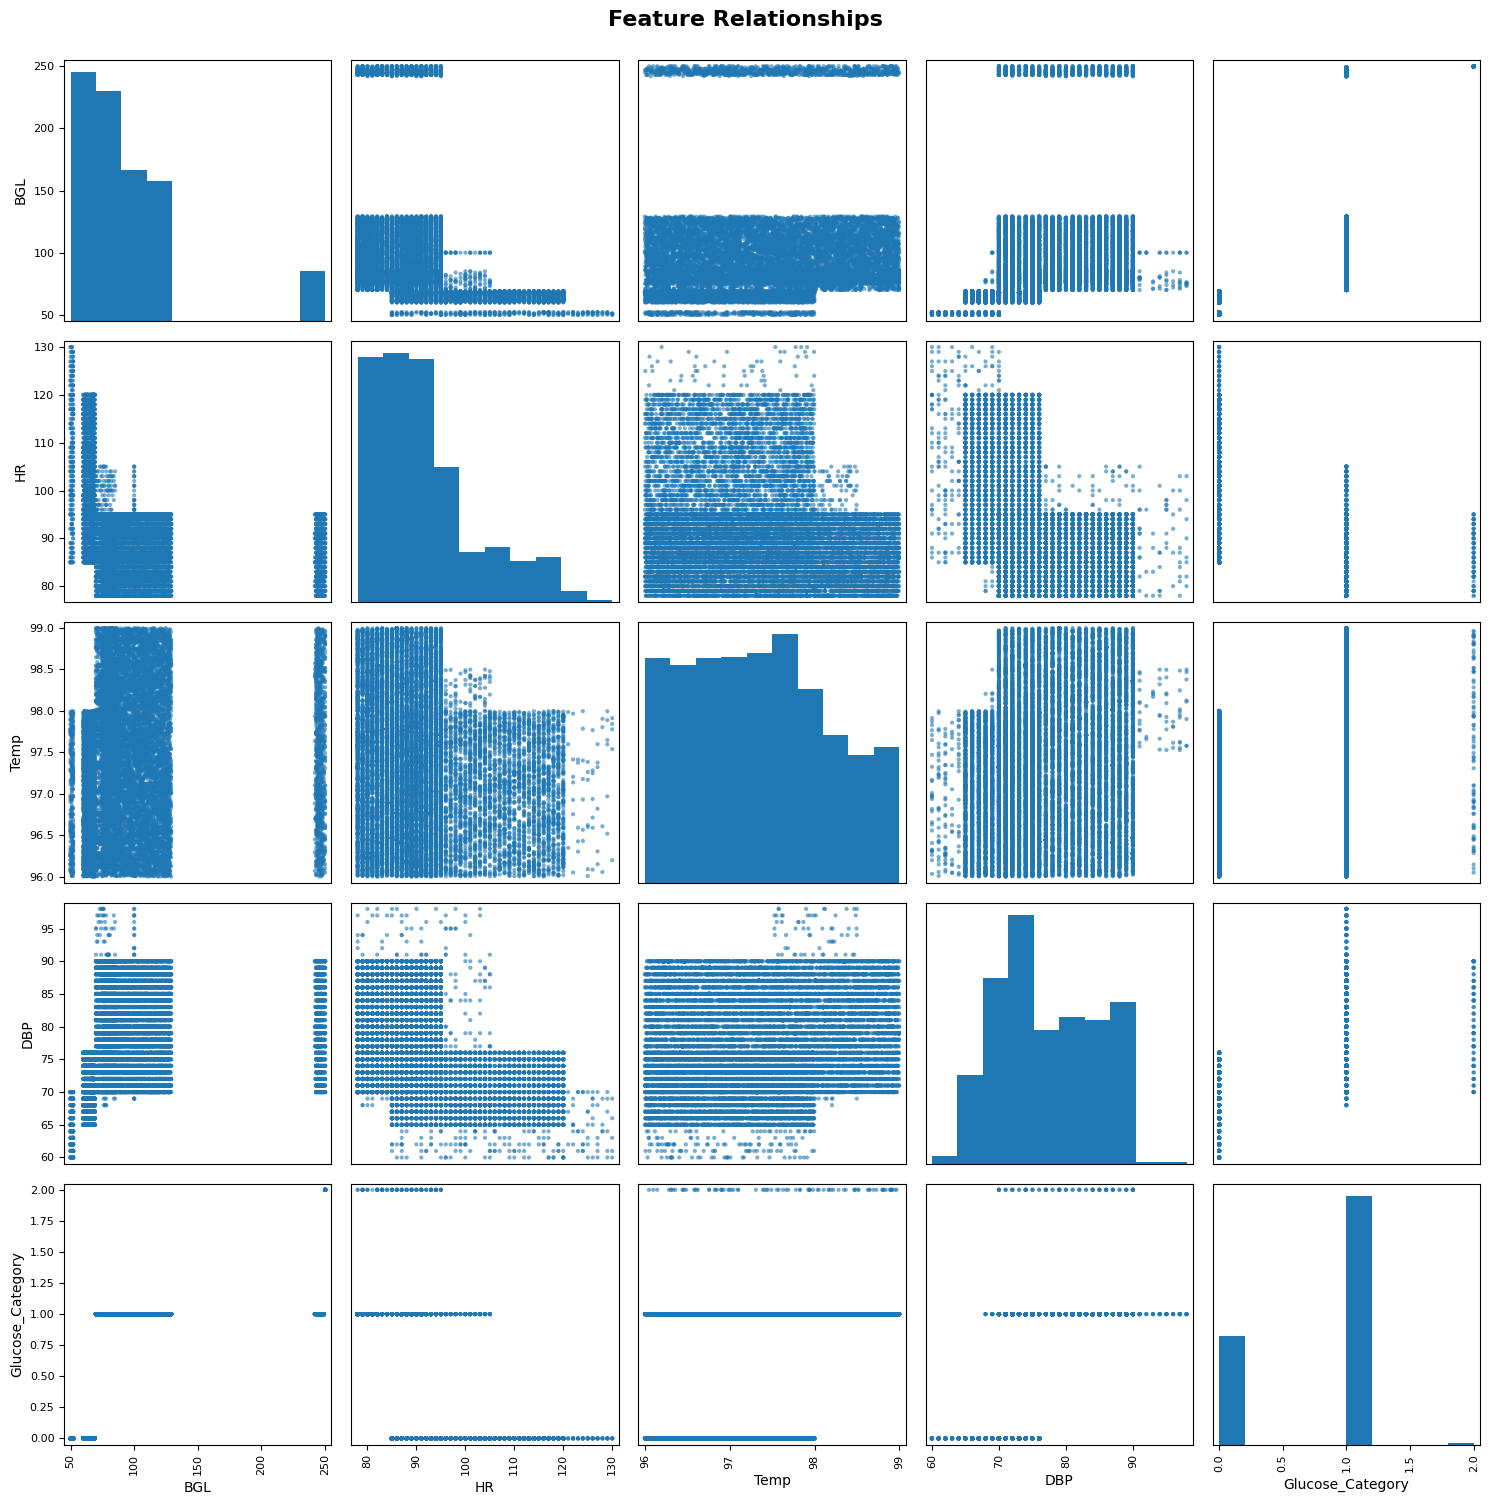

In [13]:
#Pairplot for key features
from pandas.plotting import scatter_matrix
key_features = df[['BGL', 'HR', 'Temp', 'DBP', 'Glucose_Category']]
scatter_matrix(key_features, figsize=(15, 15), alpha=0.6, diagonal='hist')
plt.suptitle('Feature Relationships', y=1.0, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### DATA AUGMENTATION FOR HYPERGLYCEMIA

In [14]:
def augment_hyperglycemia(df, target_count=500):
    hyper_samples = df[df['Glucose_Category'] == 2].copy()
    current_count = len(hyper_samples)
    
    print(f"\nOriginal Hyperglycemia samples: {current_count}")
    print(f"Target Hyperglycemia samples: {target_count}")
    
    if current_count >= target_count:
        print("No augmentation needed")
        return df
    
    samples_needed = target_count - current_count
    
    # Method 1: Noise injection (60% of needed samples)
    noise_samples = int(samples_needed * 0.6)
    augmented_data = []
    
    for _ in range(noise_samples):
        # Randomly select a hyperglycemia sample
        base_sample = hyper_samples.sample(1).iloc[0].copy()
        
        # Add controlled noise to continuous features
        noise_factors = {
            'BGL': np.random.normal(0, 5),
            'DBP': np.random.normal(0, 2),
            'SBP': np.random.normal(0, 3),
            'HR': np.random.normal(0, 2),
            'Temp': np.random.normal(0, 0.1),
            'SPO2': np.random.normal(0, 0.5)
        }
        
        for feature, noise in noise_factors.items():
            base_sample[feature] += noise
        
        # Keep BGL > 250 for hyperglycemia
        base_sample['BGL'] = max(250, min(400, base_sample['BGL']))
        base_sample['Glucose_Category'] = 2
        
        # Ensure categorical features remain valid
        base_sample['Sweating'] = np.clip(base_sample['Sweating'], 0, 1)
        base_sample['Shivering'] = np.clip(base_sample['Shivering'], 0, 1)
        
        augmented_data.append(base_sample)
    
    # Method 2: Interpolation (40% of needed samples)
    interp_samples = samples_needed - noise_samples
    
    for _ in range(interp_samples):
        # Select two random hyperglycemia samples
        if len(hyper_samples) >= 2:
            samples = hyper_samples.sample(2)
            # Interpolate between them
            alpha = np.random.uniform(0.3, 0.7)
            new_sample = samples.iloc[0] * alpha + samples.iloc[1] * (1 - alpha)
            new_sample['Glucose_Category'] = 2
            new_sample['BGL'] = max(250, new_sample['BGL'])
            
            # Ensure categorical features remain valid
            for col in ['Sweating', 'Shivering']:
                new_sample[col] = round(np.clip(new_sample[col], 0, 1))
                
            augmented_data.append(new_sample)
    
    # Combine original and augmented data
    augmented_df = pd.DataFrame(augmented_data)
    df_balanced = pd.concat([df, augmented_df], ignore_index=True)
    
    print(f"Generated {len(augmented_data)} synthetic hyperglycemia samples")
    print(f"\nNew distribution:")
    new_counts = df_balanced['Glucose_Category'].value_counts().sort_index()
    print(f"Hypoglycemia (0): {new_counts.get(0, 0)}")
    print(f"Normal (1): {new_counts.get(1, 0)}")
    print(f"Hyperglycemia (2): {new_counts.get(2, 0)}")
    
    return df_balanced

# Apply augmentation
df_balanced = augment_hyperglycemia(df, target_count=500)


Original Hyperglycemia samples: 83
Target Hyperglycemia samples: 500
Generated 417 synthetic hyperglycemia samples

New distribution:
Hypoglycemia (0): 5147
Normal (1): 11739
Hyperglycemia (2): 500


### FEATURE SCALING

In [15]:
feature_cols = ['BGL', 'DBP', 'SBP', 'HR', 'Temp', 'SPO2', 'Sweating', 'Shivering']
df_features = df_balanced[feature_cols].copy()

# Normalize features
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=feature_cols
)


# Save scaler
joblib.dump(scaler, r'C:\Users\HP\Downloads\Nandhini_Majorproject\modelsscaler.pkl')
print(" Scaler saved to models/scaler.pkl")

 Scaler saved to models/scaler.pkl


### SINGLE-STEP MULTI-HORIZON SEQUENCE CREATION

**Input:** Last 1 measurement `(SEQ_LENGTH = 1)` → 8 features treated as 8 tokens  
**Horizons:** 5, 10, 15, 30, 60 minutes  
**Architecture:** Transformer Encoder → BiLSTM (feature-as-token design)

In [ ]:
# ══════════════════════════════════════════════════════════════
SEQ_LENGTH          = 1
SAMPLING_MIN        = 1            # set 5 for 5-min CGM devices
PREDICTION_HORIZONS = [5, 10, 15, 30, 60]
HORIZON_STEPS       = [h // SAMPLING_MIN for h in PREDICTION_HORIZONS]

print("=" * 55)
print(f"  SEQ_LENGTH          : {SEQ_LENGTH}  (last 1 reading)")
print(f"  PREDICTION_HORIZONS : {PREDICTION_HORIZONS} minutes")
print(f"  HORIZON_STEPS       : {HORIZON_STEPS} timesteps")
print("=" * 55)


def create_single_step_sequences(data, df_original,
                                  seq_length    = SEQ_LENGTH,
                                  horizon_steps = HORIZON_STEPS):
    """
    X             : (N, 1, 8)   — single scaled measurement
    y_regression  : (N, 5)      — BGL at each future horizon
    y_classification : (N,)     — category at furthest horizon
    """
    X, y_reg_d, y_cls = [], {h: [] for h in horizon_steps}, []
    max_h = max(horizon_steps)

    for i in range(len(data) - seq_length - max_h + 1):
        X.append(data[i : i + seq_length])
        for h in horizon_steps:
            y_reg_d[h].append(df_original.iloc[i + seq_length + h - 1]['BGL'])
        y_cls.append(df_original.iloc[i + seq_length + max_h - 1]['Glucose_Category'])

    X               = np.array(X)
    y_regression    = np.column_stack([y_reg_d[h] for h in horizon_steps])
    y_classification = np.array(y_cls)
    return X, y_regression, y_classification, horizon_steps


X, y_regression, y_classification, horizons = create_single_step_sequences(
    df_scaled.values, df_balanced,
    seq_length=SEQ_LENGTH, horizon_steps=HORIZON_STEPS
)

print(f"X shape            : {X.shape}   ← (samples, 1, 8)")
print(f"y_regression shape : {y_regression.shape}")
print(f"y_classification   : {y_classification.shape}")
print(f"Class counts       : {dict(Counter(y_classification))}")


  SEQ_LENGTH          : 1  (last 1 reading)
  PREDICTION_HORIZONS : [5, 10, 15, 30, 60] minutes
  HORIZON_STEPS       : [5, 10, 15, 30, 60] timesteps
X shape            : (17326, 1, 8)   ← (samples, 1, 8)
y_regression shape : (17326, 5)
y_classification   : (17326,)
Class counts       : {1.0: 11679, 0.0: 5147, 2.0: 500}


### APPLY SMOTE TO BALANCE CATEGORIES

In [ ]:
X_flat = X.reshape(X.shape[0], -1)

print("Class distribution before SMOTE:")
print(Counter(y_classification))

class_counts = Counter(y_classification)
normal_count = class_counts[1]
target_hypo  = int(normal_count * 0.8)
target_hyper = int(normal_count * 0.4)

smote = SMOTE(
    sampling_strategy={0: target_hypo, 2: target_hyper},
    random_state=42,
    k_neighbors=min(5, min(target_hypo, target_hyper) - 1)
)
X_flat_resampled, y_cat_resampled = smote.fit_resample(X_flat, y_classification)

y_reg_resampled = np.zeros((X_flat_resampled.shape[0], y_regression.shape[1]))
synthetic_mask  = np.arange(len(X_flat_resampled)) >= len(X_flat)
y_reg_resampled[~synthetic_mask] = y_regression

for i in np.where(synthetic_mask)[0]:
    cat = y_cat_resampled[i]
    if   cat == 0: bgl = np.random.uniform(50,  70,  len(PREDICTION_HORIZONS))
    elif cat == 1: bgl = np.random.uniform(70,  250, len(PREDICTION_HORIZONS))
    else:          bgl = np.random.uniform(250, 400, len(PREDICTION_HORIZONS))
    y_reg_resampled[i] = bgl

X_resampled = X_flat_resampled.reshape(-1, SEQ_LENGTH, len(feature_cols))

print("Class distribution after SMOTE:", Counter(y_cat_resampled))
print(f"X_resampled shape  : {X_resampled.shape}")
print(f"y_reg_resampled    : {y_reg_resampled.shape}")


Class distribution before SMOTE:
Counter({1.0: 11679, 0.0: 5147, 2.0: 500})
Class distribution after SMOTE: Counter({1.0: 11679, 0.0: 9343, 2.0: 4671})
X_resampled shape  : (25693, 1, 8)
y_reg_resampled    : (25693, 5)


### TRAIN-VAL-TEST SPLIT

In [18]:
from sklearn.preprocessing import StandardScaler as TargetScaler

# ── SPLIT ────────────────────────────────────────────────────────────────
X_temp, X_test, y_reg_temp, y_reg_test, y_cat_temp, y_cat_test = train_test_split(
    X_resampled, y_reg_resampled, y_cat_resampled,
    test_size=0.15, random_state=42, stratify=y_cat_resampled
)
X_train, X_val, y_reg_train, y_reg_val, y_cat_train, y_cat_val = train_test_split(
    X_temp, y_reg_temp, y_cat_temp,
    test_size=0.1765, random_state=42, stratify=y_cat_temp
)

# ── NORMALISE REGRESSION TARGETS ─────────────────────────────────────────
bgl_target_scaler = TargetScaler()
y_reg_train_scaled = bgl_target_scaler.fit_transform(y_reg_train)
y_reg_val_scaled   = bgl_target_scaler.transform(y_reg_val)
y_reg_test_scaled  = bgl_target_scaler.transform(y_reg_test)

print(f"Train  : {X_train.shape[0]:>7,}  ({X_train.shape[0]/len(X_resampled)*100:.1f}%)")
print(f"Val    : {X_val.shape[0]:>7,}  ({X_val.shape[0]/len(X_resampled)*100:.1f}%)")
print(f"Test   : {X_test.shape[0]:>7,}  ({X_test.shape[0]/len(X_resampled)*100:.1f}%)")
print(f"Target range  → raw: {y_reg_train.min():.1f}–{y_reg_train.max():.1f} mg/dL  |  "
      f"scaled: {y_reg_train_scaled.min():.3f}–{y_reg_train_scaled.max():.3f}")


Train  :  17,984  (70.0%)
Val    :   3,855  (15.0%)
Test   :   3,854  (15.0%)
Target range  → raw: 50.0–400.0 mg/dL  |  scaled: -0.819–2.785


In [19]:

import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error, mean_absolute_error

os.makedirs("models", exist_ok=True)

def r2_metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1.0 - ss_res / (ss_tot + tf.keras.backend.epsilon())

N_TIMESTEPS = X_train.shape[1]
N_FEATURES  = X_train.shape[2]
N_HORIZONS  = y_reg_train_scaled.shape[1]
N_CLASSES   = len(np.unique(y_cat_train))
print(f"Input: ({N_TIMESTEPS}, {N_FEATURES})  |  Horizons: {N_HORIZONS}  |  Classes: {N_CLASSES}")

def make_callbacks(name, patience=25, lr_patience=8):
    return [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f"models/{name}.keras", monitor="val_loss",
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=lr_patience, min_lr=1e-7, verbose=1),
    ]

def compile_model(m, lr=5e-4):
    # Adam with clipnorm - compatible with TF 2.x and Python 3.9
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    m.compile(
        optimizer=optimizer,
        loss={
            "glucose_values":   tf.keras.losses.Huber(delta=1.0),
            "glucose_category": "sparse_categorical_crossentropy"
        },
        loss_weights={"glucose_values": 1.0, "glucose_category": 0.25},
        metrics={
            "glucose_values":   ["mae", "mse", r2_metric],
            "glucose_category": ["accuracy"]
        }
    )
    return m

def evaluate_model(name, m):
    def avg_metrics(y_true, y_pred):
        rmse = float(np.mean([np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i]))
                               for i in range(y_true.shape[1])]))
        mae  = float(np.mean([mean_absolute_error(y_true[:,i], y_pred[:,i])
                               for i in range(y_true.shape[1])]))
        r2   = float(np.mean([r2_score(y_true[:,i], y_pred[:,i])
                               for i in range(y_true.shape[1])]))
        return rmse, mae, r2

    tr_rs, tr_cs = m.predict(X_train, verbose=0)
    vl_rs, vl_cs = m.predict(X_val,   verbose=0)
    te_rs, te_cs = m.predict(X_test,  verbose=0)

    tr_r = bgl_target_scaler.inverse_transform(tr_rs)
    vl_r = bgl_target_scaler.inverse_transform(vl_rs)
    te_r = bgl_target_scaler.inverse_transform(te_rs)

    tr_rmse, tr_mae, tr_r2 = avg_metrics(y_reg_train, tr_r)
    vl_rmse, vl_mae, vl_r2 = avg_metrics(y_reg_val,   vl_r)
    te_rmse, te_mae, te_r2 = avg_metrics(y_reg_test,  te_r)
    tr_acc = accuracy_score(y_cat_train, np.argmax(tr_cs, axis=1))
    vl_acc = accuracy_score(y_cat_val,   np.argmax(vl_cs, axis=1))
    te_acc = accuracy_score(y_cat_test,  np.argmax(te_cs, axis=1))

    sep = "="*60
    print(f"\n{sep}\n  {name}\n{sep}")
    print(f"  {'':20s} {'Train':>10s} {'Val':>10s} {'Test':>10s}")
    print(f"  {'RMSE (mg/dL)':20s} {tr_rmse:10.4f} {vl_rmse:10.4f} {te_rmse:10.4f}")
    print(f"  {'MAE  (mg/dL)':20s} {tr_mae:10.4f}  {vl_mae:10.4f}  {te_mae:10.4f}")
    print(f"  {'R2':20s} {tr_r2:10.4f} {vl_r2:10.4f} {te_r2:10.4f}")
    print(f"  {'Accuracy':20s} {tr_acc:10.4f} {vl_acc:10.4f} {te_acc:10.4f}")
    return {
        "Model": name,
        "Train_RMSE": tr_rmse, "Val_RMSE": vl_rmse, "Test_RMSE": te_rmse,
        "Train_R2":   tr_r2,   "Val_R2":   vl_r2,   "Test_R2":   te_r2,
        "Train_Acc":  tr_acc,  "Val_Acc":  vl_acc,  "Test_Acc":  te_acc,
    }


Input: (1, 8)  |  Horizons: 5  |  Classes: 3


###  Transformer-BiLSTM  
`d_model=32 | heads=2 | blocks=2 | ff=64 | BiLSTM=64 | batch=256`  
**Target: ~10 sec/epoch on i3 CPU**

In [20]:

def transformer_block_fast(inputs, d_model, num_heads, ff_dim,
                            dropout=0.1, block_idx=0):
    p    = f"blk{block_idx}_"
    x    = layers.LayerNormalization(epsilon=1e-6, name=p+"ln1")(inputs)
    attn = layers.MultiHeadAttention(
               num_heads=num_heads,
               key_dim=d_model // num_heads,
               dropout=dropout, name=p+"mha")(x, x)
    attn = layers.Dropout(dropout, name=p+"do1")(attn)
    x    = layers.Add(name=p+"add1")([inputs, attn])
    ff   = layers.LayerNormalization(epsilon=1e-6, name=p+"ln2")(x)
    ff   = layers.Dense(ff_dim, activation="relu", name=p+"ff1")(ff)
    ff   = layers.Dropout(dropout, name=p+"do2")(ff)
    ff   = layers.Dense(d_model, name=p+"ff2")(ff)
    ff   = layers.Dropout(dropout, name=p+"do3")(ff)
    return layers.Add(name=p+"add2")([x, ff])


def build_fast_transformer_bilstm(
        seq_length=N_TIMESTEPS, n_features=N_FEATURES,
        n_horizons=N_HORIZONS,  n_classes=N_CLASSES,
        d_model=32, num_heads=2, ff_dim=64,
        num_blocks=2, lstm_units=64,
        dropout=0.1):
    """
    Lightweight Transformer+BiLSTM for i3 CPU.
    ~10s/epoch at batch=256.  Good accuracy with small param count.
    """
    inputs = layers.Input(shape=(seq_length, n_features),
                          name="glucose_input")

    # Feature-as-token: (B,1,8) -> (B,8,d_model)
    x = layers.Permute((2, 1), name="feature_as_token")(inputs)
    x = layers.Dense(d_model, name="token_proj")(x)

    # Positional encoding (fixed, no batch dim issue)
    pos_embed = layers.Embedding(n_features, d_model,
                                  name="pos_embed")(tf.range(n_features))
    pos_embed = tf.expand_dims(pos_embed, 0)   # (1,8,d_model) broadcasts
    x = layers.Add(name="add_pos")([x, pos_embed])
    x = layers.Dropout(dropout, name="input_drop")(x)

    # 2 lightweight transformer blocks
    for i in range(num_blocks):
        x = transformer_block_fast(x, d_model, num_heads,
                                    ff_dim, dropout, block_idx=i)

    # Single BiLSTM (return_sequences=False for speed)
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=False),
            name="bilstm")(x)
    x = layers.Dropout(dropout, name="bilstm_drop")(x)

    # Compact dense head
    x = layers.Dense(128, activation="relu", name="dense_1")(x)
    x = layers.Dropout(dropout, name="drop_1")(x)
    x = layers.Dense(64,  activation="relu", name="dense_2")(x)

    out_reg = layers.Dense(n_horizons, name="glucose_values")(x)
    out_cls = layers.Dense(n_classes, activation="softmax",
                            name="glucose_category")(x)

    m = Model(inputs, [out_reg, out_cls],
              name="Fast_Transformer_BiLSTM")
    return compile_model(m, lr=5e-4)

model_tf = build_fast_transformer_bilstm()
model_tf.summary()
print(f"\nTotal params: {model_tf.count_params():,}")


Model: "Fast_Transformer_BiLSTM"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 glucose_input (InputLayer)     [(None, 1, 8)]       0           []                               
                                                                                                  
 feature_as_token (Permute)     (None, 8, 1)         0           ['glucose_input[0][0]']          
                                                                                                  
 token_proj (Dense)             (None, 8, 32)        64          ['feature_as_token[0][0]']       
                                                                                                  
 add_pos (Add)                  (None, 8, 32)        0           ['token_proj[0][0]']             
                                                                            

In [21]:

train_data = {"glucose_values": y_reg_train_scaled,
              "glucose_category": y_cat_train}
val_data   = {"glucose_values": y_reg_val_scaled,
              "glucose_category": y_cat_val}

history_tf = model_tf.fit(
    X_train, train_data,
    validation_data=(X_val, val_data),
    epochs=200,
    batch_size=256,       # large batch = fewer steps = fast epoch
    callbacks=make_callbacks("fast_transformer_bilstm",
                              patience=20, lr_patience=7),
    verbose=1
)
print(f"Best val_loss : {min(history_tf.history['val_loss']):.6f}")

Epoch 1/200
70/71 [============================>.] - ETA: 0s - loss: 0.3646 - glucose_values_loss: 0.1940 - glucose_category_loss: 0.6824 - glucose_values_mae: 0.4403 - glucose_values_mse: 0.4884 - glucose_values_r2_metric: 0.5083 - glucose_category_accuracy: 0.7066
Epoch 1: val_loss improved from inf to 0.15329, saving model to models\fast_transformer_bilstm.keras
71/71 [==============================] - 27s 146ms/step - loss: 0.3643 - glucose_values_loss: 0.1939 - glucose_category_loss: 0.6816 - glucose_values_mae: 0.4400 - glucose_values_mse: 0.4883 - glucose_values_r2_metric: 0.5105 - glucose_category_accuracy: 0.7072 - val_loss: 0.1533 - val_glucose_values_loss: 0.0748 - val_glucose_category_loss: 0.3140 - val_glucose_values_mae: 0.2095 - val_glucose_values_mse: 0.1996 - val_glucose_values_r2_metric: 0.8057 - val_glucose_category_accuracy: 0.9038 - lr: 5.0000e-04
Epoch 2/200
70/71 [============================>.] - ETA: 0s - loss: 0.1660 - glucose_values_loss: 0.0861 - glucose_cat

### FAST CNN-BiGRU-Attention  
`Filters=[64,128] | GRU=64 | 4-head attn | batch=256`  
**Target: ~8 sec/epoch on i3 CPU**

In [22]:

def build_fast_cnn_bigru(
        seq_length=N_TIMESTEPS, n_features=N_FEATURES,
        n_horizons=N_HORIZONS,  n_classes=N_CLASSES,
        filters=[64, 128], gru_units=64,
        attn_heads=4, dropout=0.15):
    """Fast CNN-BiGRU for i3 CPU. ~8s/epoch at batch=256."""
    inputs = layers.Input(shape=(seq_length, n_features),
                          name="glucose_input")

    # CNN Block 1
    x = layers.Conv1D(filters[0], 3, padding="same",
                      activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # CNN Block 2
    x = layers.Conv1D(filters[1], 3, padding="same",
                      activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Single BiGRU
    x = layers.Bidirectional(
            layers.GRU(gru_units, return_sequences=True))(x)
    x = layers.Dropout(dropout)(x)

    # Lightweight multi-head attention
    d    = x.shape[-1]
    attn = layers.MultiHeadAttention(
               num_heads=attn_heads,
               key_dim=max(d // attn_heads, 1))(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(attn + x)

    # Dual pool
    avg = layers.GlobalAveragePooling1D()(attn)
    mx  = layers.GlobalMaxPooling1D()(attn)
    x   = layers.Concatenate()([avg, mx])

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64,  activation="relu")(x)

    out_reg = layers.Dense(n_horizons, name="glucose_values")(x)
    out_cls = layers.Dense(n_classes, activation="softmax",
                            name="glucose_category")(x)

    m = Model(inputs, [out_reg, out_cls],
              name="Fast_CNN_BiGRU_Attn")
    return compile_model(m, lr=5e-4)

model_cnn = build_fast_cnn_bigru()
model_cnn.summary()
print(f"\nTotal params: {model_cnn.count_params():,}")


Model: "Fast_CNN_BiGRU_Attn"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 glucose_input (InputLayer)     [(None, 1, 8)]       0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 1, 64)        1600        ['glucose_input[0][0]']          
                                                                                                  
 batch_normalization (BatchNorm  (None, 1, 64)       256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 dropout (Dropout)              (None, 1, 64)        0           ['batch_normali

In [23]:

history_cnn = model_cnn.fit(
    X_train, train_data,
    validation_data=(X_val, val_data),
    epochs=200,
    batch_size=256,
    callbacks=make_callbacks("fast_cnn_bigru",
                              patience=20, lr_patience=7),
    verbose=1
)
print(f"Best val_loss : {min(history_cnn.history['val_loss']):.6f}")


Epoch 1/200
69/71 [============================>.] - ETA: 0s - loss: 0.2889 - glucose_values_loss: 0.1900 - glucose_category_loss: 0.3957 - glucose_values_mae: 0.4596 - glucose_values_mse: 0.4604 - glucose_values_r2_metric: 0.5341 - glucose_category_accuracy: 0.8657
Epoch 1: val_loss improved from inf to 0.15758, saving model to models\fast_cnn_bigru.keras
71/71 [==============================] - 10s 31ms/step - loss: 0.2873 - glucose_values_loss: 0.1889 - glucose_category_loss: 0.3936 - glucose_values_mae: 0.4575 - glucose_values_mse: 0.4579 - glucose_values_r2_metric: 0.5380 - glucose_category_accuracy: 0.8667 - val_loss: 0.1576 - val_glucose_values_loss: 0.0880 - val_glucose_category_loss: 0.2783 - val_glucose_values_mae: 0.2830 - val_glucose_values_mse: 0.2154 - val_glucose_values_r2_metric: 0.7904 - val_glucose_category_accuracy: 0.9045 - lr: 5.0000e-04
Epoch 2/200
69/71 [============================>.] - ETA: 0s - loss: 0.1579 - glucose_values_loss: 0.0943 - glucose_category_loss

### FAST TCN-BiGRU  
`Filters=[64,64,128] | Dilations=[1,2,4] | GRU=64 | batch=256`  
**Target: ~6 sec/epoch on i3 CPU**

In [24]:

def fast_tcn_block(x, filters, kernel_size, dilation, dropout=0.1):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)
    y = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation, activation="relu")(x)
    y = layers.BatchNormalization()(y)
    y = layers.SpatialDropout1D(dropout)(y)
    y = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation, activation="relu")(y)
    y = layers.BatchNormalization()(y)
    y = layers.SpatialDropout1D(dropout)(y)
    return layers.Activation("relu")(layers.Add()([shortcut, y]))


def build_fast_tcn_bigru(
        seq_length=N_TIMESTEPS, n_features=N_FEATURES,
        n_horizons=N_HORIZONS,  n_classes=N_CLASSES,
        filter_seq=[64, 64, 128],
        dilations=[1, 2, 4],
        gru_units=64, dropout=0.1):
    """Fast TCN for i3 CPU. ~6s/epoch at batch=256."""
    inputs = layers.Input(shape=(seq_length, n_features),
                          name="glucose_input")

    x = layers.Conv1D(filter_seq[0], 1, padding="same")(inputs)
    for filt, dil in zip(filter_seq, dilations):
        x = fast_tcn_block(x, filt, kernel_size=3,
                            dilation=dil, dropout=dropout)

    # Single BiGRU + dual pool
    x = layers.Bidirectional(
            layers.GRU(gru_units, return_sequences=True))(x)
    avg = layers.GlobalAveragePooling1D()(x)
    mx  = layers.GlobalMaxPooling1D()(x)
    x   = layers.Concatenate()([avg, mx])

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64,  activation="relu")(x)

    out_reg = layers.Dense(n_horizons, name="glucose_values")(x)
    out_cls = layers.Dense(n_classes, activation="softmax",
                            name="glucose_category")(x)

    m = Model(inputs, [out_reg, out_cls], name="Fast_TCN_BiGRU")
    return compile_model(m, lr=5e-4)

model_tcn = build_fast_tcn_bigru()
model_tcn.summary()
print(f"\nTotal params: {model_tcn.count_params():,}")


Model: "Fast_TCN_BiGRU"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 glucose_input (InputLayer)     [(None, 1, 8)]       0           []                               
                                                                                                  
 conv1d_2 (Conv1D)              (None, 1, 64)        576         ['glucose_input[0][0]']          
                                                                                                  
 conv1d_3 (Conv1D)              (None, 1, 64)        12352       ['conv1d_2[0][0]']               
                                                                                                  
 batch_normalization_2 (BatchNo  (None, 1, 64)       256         ['conv1d_3[0][0]']               
 rmalization)                                                                        

In [25]:

history_tcn = model_tcn.fit(
    X_train, train_data,
    validation_data=(X_val, val_data),
    epochs=200,
    batch_size=256,
    callbacks=make_callbacks("fast_tcn_bigru",
                              patience=20, lr_patience=7),
    verbose=1
)
print(f"Best val_loss : {min(history_tcn.history['val_loss']):.6f}")


Epoch 1/200
71/71 [==============================] - ETA: 0s - loss: 0.2877 - glucose_values_loss: 0.1619 - glucose_category_loss: 0.5031 - glucose_values_mae: 0.3923 - glucose_values_mse: 0.4004 - glucose_values_r2_metric: 0.5980 - glucose_category_accuracy: 0.8012
Epoch 1: val_loss improved from inf to 0.47217, saving model to models\fast_tcn_bigru.keras
71/71 [==============================] - 14s 96ms/step - loss: 0.2877 - glucose_values_loss: 0.1619 - glucose_category_loss: 0.5031 - glucose_values_mae: 0.3923 - glucose_values_mse: 0.4004 - glucose_values_r2_metric: 0.5980 - glucose_category_accuracy: 0.8012 - val_loss: 0.4722 - val_glucose_values_loss: 0.2841 - val_glucose_category_loss: 0.7523 - val_glucose_values_mae: 0.6219 - val_glucose_values_mse: 0.6821 - val_glucose_values_r2_metric: 0.3175 - val_glucose_category_accuracy: 0.7092 - lr: 5.0000e-04
Epoch 2/200
70/71 [============================>.] - ETA: 0s - loss: 0.1413 - glucose_values_loss: 0.0796 - glucose_category_loss

### Model Evaluation — All Models

In [33]:

results = []
results.append(evaluate_model("Transformer-BiLSTM",        model_tf))
results.append(evaluate_model("CNN-BiGRU-MultiHeadAttn",   model_cnn))
results.append(evaluate_model("TCN-BiGRU",                 model_tcn))

import pandas as pd
df_res = pd.DataFrame(results)
df_res["Combined"] = 0.5 * df_res["Test_R2"] + 0.5 * df_res["Test_Acc"]
df_res = df_res.sort_values("Combined", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("                 FINAL MODEL COMPARISON (Test Set)")
print("="*70)
display(df_res[["Model","Test_RMSE","Test_R2","Test_Acc","Combined"]].round(4))
best = df_res.iloc[0]
print(f"\n BEST MODEL : {best['Model']}")
print(f"   Test RMSE  : {best['Test_RMSE']:.2f} mg/dL")
print(f"   Test R²    : {best['Test_R2']:.4f}")
print(f"   Test Acc   : {best['Test_Acc']*100:.2f}%")


  Transformer-BiLSTM
                            Train        Val       Test
  RMSE (mg/dL)            29.0659    33.8332    37.1958
  MAE  (mg/dL)            12.9609     14.3764     15.5408
  R2                       0.9111     0.8797     0.8533
  Accuracy                 0.9753     0.9660     0.9533

  CNN-BiGRU-MultiHeadAttn
                            Train        Val       Test
  RMSE (mg/dL)            28.4655    32.3281    33.7994
  MAE  (mg/dL)            14.1681     15.2928     15.7703
  R2                       0.9147     0.8902     0.8789
  Accuracy                 0.9896     0.9842     0.9795

  TCN-BiGRU
                            Train        Val       Test
  RMSE (mg/dL)            26.5587    31.4509    33.3388
  MAE  (mg/dL)            12.5965     13.7979     14.4183
  R2                       0.9258     0.8960     0.8821
  Accuracy                 0.9897     0.9829     0.9821

                 FINAL MODEL COMPARISON (Test Set)


,Model,Test_RMSE,Test_R2,Test_Acc,Combined
0,TCN-BiGRU,33.3388,0.8821,0.9821,0.9321
1,CNN-BiGRU-MultiHeadAttn,33.7994,0.8789,0.9795,0.9292
2,Transformer-BiLSTM,37.1958,0.8533,0.9533,0.9033



 BEST MODEL : TCN-BiGRU
   Test RMSE  : 33.34 mg/dL
   Test R²    : 0.8821
   Test Acc   : 98.21%


In [34]:

def detailed_horizon_metrics(name, m, horizons=PREDICTION_HORIZONS):
    te_rs, _ = m.predict(X_test, verbose=0)
    te_r = bgl_target_scaler.inverse_transform(te_rs)
    print(f"\n{'*'*60}")
    print(f"  MODEL: {name}  — Per-Horizon Test Metrics")
    print(f"{'*'*60}")
    print(f"{'Horizon':>12s}  {'RMSE':>10s}  {'MAE':>10s}  {'R²':>10s}")
    for i, h in enumerate(horizons):
        rmse = np.sqrt(mean_squared_error(y_reg_test[:,i], te_r[:,i]))
        mae  = mean_absolute_error(y_reg_test[:,i], te_r[:,i])
        r2   = r2_score(y_reg_test[:,i], te_r[:,i])
        print(f"{f'+{h} min':>12s}  {rmse:10.4f}  {mae:10.4f}  {r2:10.4f}")

detailed_horizon_metrics("Transformer-BiLSTM",      model_tf)
detailed_horizon_metrics("CNN-BiGRU-MultiHeadAttn", model_cnn)
detailed_horizon_metrics("TCN-BiGRU",               model_tcn)


************************************************************
  MODEL: Transformer-BiLSTM  — Per-Horizon Test Metrics
************************************************************
     Horizon        RMSE         MAE          R²
      +5 min     36.9639     15.3802      0.8561
     +10 min     37.2499     15.5335      0.8541
     +15 min     36.8308     15.4045      0.8544
     +30 min     38.2129     15.7099      0.8440
     +60 min     36.7217     15.6761      0.8577

************************************************************
  MODEL: CNN-BiGRU-MultiHeadAttn  — Per-Horizon Test Metrics
************************************************************
     Horizon        RMSE         MAE          R²
      +5 min     33.6644     15.6049      0.8806
     +10 min     34.1900     15.8625      0.8771
     +15 min     33.4978     15.8648      0.8796
     +30 min     34.2363     15.5741      0.8748
     +60 min     33.4087     15.9454      0.8822

************************************************

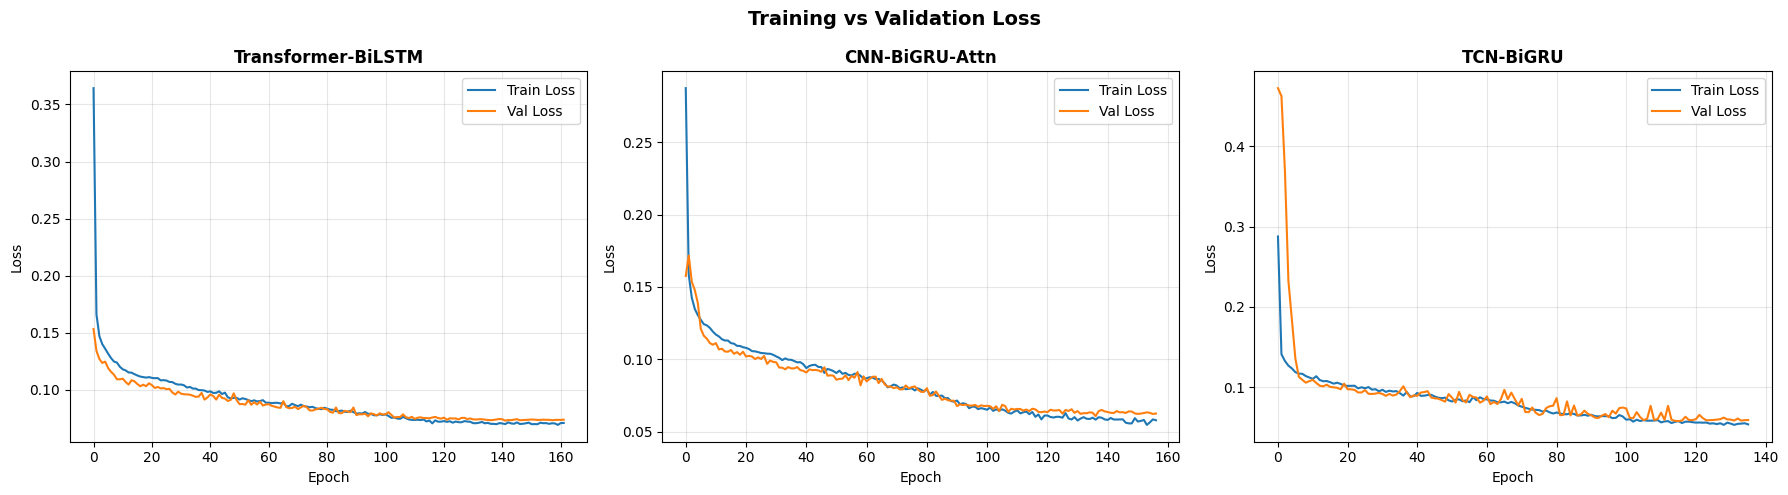

In [35]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training vs Validation Loss", fontsize=14, fontweight="bold")

for ax, hist, title in zip(
    axes,
    [history_tf.history, history_cnn.history, history_tcn.history],
    ["Transformer-BiLSTM", "CNN-BiGRU-Attn", "TCN-BiGRU"]
):
    ax.plot(hist["loss"],     label="Train Loss")
    ax.plot(hist["val_loss"], label="Val Loss")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:

import pandas as pd
import numpy as np
from sklearn.metrics import (r2_score, accuracy_score, mean_squared_error,
                              mean_absolute_error, classification_report)

HORIZONS  = [5, 10, 15, 30, 60]
CAT_NAMES = ['Hypoglycemia', 'Normal', 'Hyperglycemia']

def full_eval(name, m):
    tr_rs, tr_cs = m.predict(X_train, verbose=0)
    vl_rs, vl_cs = m.predict(X_val,   verbose=0)
    te_rs, te_cs = m.predict(X_test,  verbose=0)

    tr_r = bgl_target_scaler.inverse_transform(tr_rs)
    vl_r = bgl_target_scaler.inverse_transform(vl_rs)
    te_r = bgl_target_scaler.inverse_transform(te_rs)

    def metrics(yt, yp):
        rmse = float(np.mean([np.sqrt(mean_squared_error(yt[:,i], yp[:,i]))
                               for i in range(yt.shape[1])]))
        mae  = float(np.mean([mean_absolute_error(yt[:,i], yp[:,i])
                               for i in range(yt.shape[1])]))
        r2   = float(np.mean([r2_score(yt[:,i], yp[:,i])
                               for i in range(yt.shape[1])]))
        return rmse, mae, r2

    tr_rmse, tr_mae, tr_r2 = metrics(y_reg_train, tr_r)
    vl_rmse, vl_mae, vl_r2 = metrics(y_reg_val,   vl_r)
    te_rmse, te_mae, te_r2 = metrics(y_reg_test,  te_r)
    tr_acc = accuracy_score(y_cat_train, np.argmax(tr_cs, axis=1))
    vl_acc = accuracy_score(y_cat_val,   np.argmax(vl_cs, axis=1))
    te_acc = accuracy_score(y_cat_test,  np.argmax(te_cs, axis=1))

    sep = "*"*60
    print(f"\n{sep}\n  MODEL : {name}\n{sep}")

    print("\n  REGRESSION METRICS (avg over 5 horizons)")
    print(f"  {'':20s} {'Train':>10s} {'Val':>10s} {'Test':>10s}")
    print(f"  {'RMSE (mg/dL)':20s} {tr_rmse:10.4f} {vl_rmse:10.4f} {te_rmse:10.4f}")
    print(f"  {'MAE  (mg/dL)':20s} {tr_mae:10.4f}  {vl_mae:10.4f}  {te_mae:10.4f}")
    print(f"  {'R2':20s} {tr_r2:10.4f} {vl_r2:10.4f} {te_r2:10.4f}")

    print("\n  PER-HORIZON TEST METRICS")
    print(f"  {'Horizon':>10s}  {'RMSE':>10s}  {'MAE':>10s}  {'R2':>10s}")
    for i, h in enumerate(HORIZONS):
        h_rmse = np.sqrt(mean_squared_error(y_reg_test[:,i], te_r[:,i]))
        h_mae  = mean_absolute_error(y_reg_test[:,i], te_r[:,i])
        h_r2   = r2_score(y_reg_test[:,i], te_r[:,i])
        print(f"  {f'+{h} min':>10s}  {h_rmse:10.4f}  {h_mae:10.4f}  {h_r2:10.4f}")

    te_pred = np.argmax(te_cs, axis=1)
    print(f"\n  CLASSIFICATION (Test) — Accuracy: {te_acc:.4f}")
    print(classification_report(y_cat_test, te_pred,
                                 target_names=CAT_NAMES, digits=4))

    r2_gap  = tr_r2  - te_r2
    acc_gap = tr_acc - te_acc
    if r2_gap > 0.10:   status = "WARNING - OVERFITTING"
    elif te_r2 < 0.85:  status = "WARNING - UNDERFITTING"
    else:               status = "OK - WELL GENERALISED"
    print(f"  FITTING STATUS : {status}  (R2 gap={r2_gap:.4f}, Acc gap={acc_gap:.4f})")

    return {
        "Model": name,
        "Train_RMSE": tr_rmse, "Val_RMSE": vl_rmse, "Test_RMSE": te_rmse,
        "Train_R2":   tr_r2,   "Val_R2":   vl_r2,   "Test_R2":   te_r2,
        "Train_Acc":  tr_acc,  "Val_Acc":  vl_acc,  "Test_Acc":  te_acc,
        "R2_Gap": r2_gap, "RMSE_Gap": te_rmse - tr_rmse,
    }

# Run evaluation on all 3 models
print("="*70)
print("       COMPREHENSIVE MODEL COMPARISON -- ALL 3 MODELS")
print("="*70)

results = []
results.append(full_eval("Transformer-BiLSTM",      model_tf))
results.append(full_eval("CNN-BiGRU-MultiHeadAttn", model_cnn))
results.append(full_eval("TCN-BiGRU",               model_tcn))

# Summary table
df_cmp = pd.DataFrame(results)
df_cmp["Combined_Score"] = (
    0.4 * df_cmp["Test_R2"] +
    0.3 * df_cmp["Test_Acc"] +
    0.3 * (1 - df_cmp["Test_RMSE"] / df_cmp["Test_RMSE"].max())
)
df_cmp = df_cmp.sort_values("Combined_Score", ascending=False).reset_index(drop=True)

print("\n" + "="*75)
print("                   FINAL SUMMARY TABLE")
print("="*75)
cols = ["Model","Test_RMSE","Test_R2","Test_Acc","R2_Gap","RMSE_Gap","Combined_Score"]
print(df_cmp[cols].round(4).to_string(index=False))

# Winner
best   = df_cmp.iloc[0]
second = df_cmp.iloc[1]
third  = df_cmp.iloc[2]
margin = best["Combined_Score"] - second["Combined_Score"]

print("\n" + "#"*60)
print(f"  [1st BEST MODEL]  -->  {best['Model']}")
print(f"       Test RMSE     : {best['Test_RMSE']:.4f} mg/dL")
print(f"       Test R2       : {best['Test_R2']:.4f}  ({best['Test_R2']*100:.2f}% variance explained)")
print(f"       Test Accuracy : {best['Test_Acc']*100:.2f}%")
print(f"       Combined Score: {best['Combined_Score']:.4f}")
print(f"\n  [2nd]  {second['Model']}  (Score: {second['Combined_Score']:.4f})")
print(f"  [3rd]  {third['Model']}  (Score: {third['Combined_Score']:.4f})")
print(f"\n  Winning margin over 2nd: {margin:.4f}")
print("#"*60)


       COMPREHENSIVE MODEL COMPARISON -- ALL 3 MODELS

************************************************************
  MODEL : Transformer-BiLSTM
************************************************************

  REGRESSION METRICS (avg over 5 horizons)
                            Train        Val       Test
  RMSE (mg/dL)            29.0659    33.8332    37.1958
  MAE  (mg/dL)            12.9609     14.3764     15.5408
  R2                       0.9111     0.8797     0.8533

  PER-HORIZON TEST METRICS
     Horizon        RMSE         MAE          R2
      +5 min     36.9639     15.3802      0.8561
     +10 min     37.2499     15.5335      0.8541
     +15 min     36.8308     15.4045      0.8544
     +30 min     38.2129     15.7099      0.8440
     +60 min     36.7217     15.6761      0.8577

  CLASSIFICATION (Test) — Accuracy: 0.9533
               precision    recall  f1-score   support

 Hypoglycemia     0.9943    0.9971    0.9957      1401
       Normal     0.9570    0.9395    0.9482   

In [37]:
import joblib
model_tf.save("models/transformer_bilstm_final.keras")
model_cnn.save("models/cnn_bigru_attn_final.keras")
model_tcn.save("models/tcn_bigru_final.keras")
joblib.dump(scaler,           "models/feature_scaler.pkl")
joblib.dump(bgl_target_scaler,"models/target_scaler.pkl")
print("All models and scalers saved.")

All models and scalers saved.
